# Products of Carbon Burning

O/Ne WDs form in the cores of stars that undergo carbon burning.  Some of the trace nuclei in O/Ne cores/WDs can participate in the Urca process, which can drive cooling that can prevent O-ignition.  This may lead to an accretion-induced collapse or electron-capture supernova (see, e.g., [The importance of Urca-process cooling in accreting ONe white dwarfs](https://academic.oup.com/mnras/article/472/3/3390/4093085?login=false) by Schwab et al.

We want to understand what trace nuclei are byproducts of carbon burning.  We'll do a one-zone burn to understand.

In [1]:
import pynucastro as pyna

The major C burning processes are:

$$\begin{split}{}^{12}\mathrm{C} + {}^{12}\mathrm{C} \rightarrow \begin{cases}
       {}^{20}\mathrm{Ne} + \alpha \\
       {}^{23}\mathrm{Na} + p \\
       {}^{23}\mathrm{Mg} + n \end{cases}
\end{split}$$

We'll include some other Ne, Na, and Mg isotopes as well.

In [2]:
net = pyna.network_helper(["p", "he4", "n",
                           "c12", "o16",
                           "ne20-22", "na21-23", "mg23-25",
                           "al27", "si27,28"])

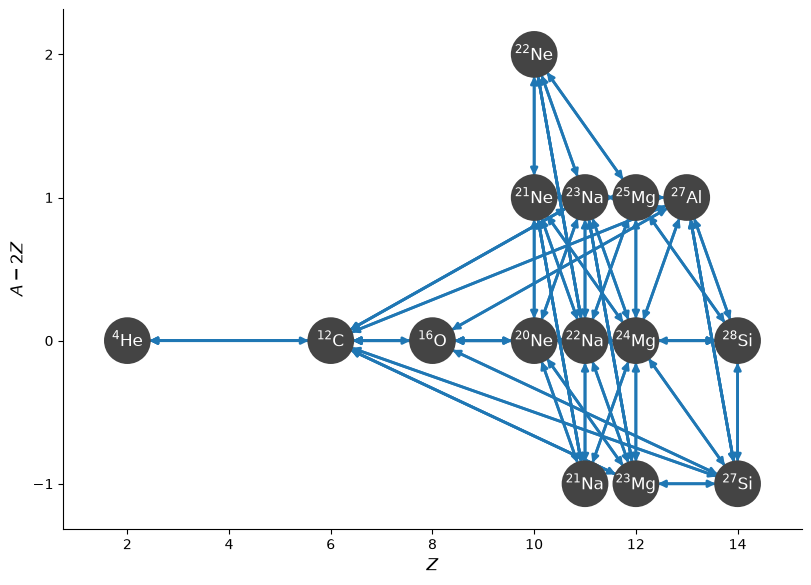

In [3]:
fig = net.plot(rotated=True)

We'll assume conditions where we expect C burning to occur.  Our results will be very sensitive to temperature.

In [4]:
comp = pyna.Composition(net.unique_nuclei)
comp.X[pyna.Nucleus("c12")] = 0.5
comp.X[pyna.Nucleus("o16")] = 0.5

In [5]:
rho = 1.e8
T = 1.e9

Now we can burn, assuming that the thermodynamic conditions are fixed.  We'll burn until carbon is depleted.

In [6]:
tmax = 1.e8
sol = net.integrate_network(tmax, rho, T, comp,
                            screen_method="chugunov_2007",
                            stopping_condition=("c12", 1.e-3),
                            rtol=1.e-6, atol=1.e-8)

/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:129: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))


/home/zingale/development/pynucastro/pynucastro/networks/python_network.py:508: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(tmin, tmax)


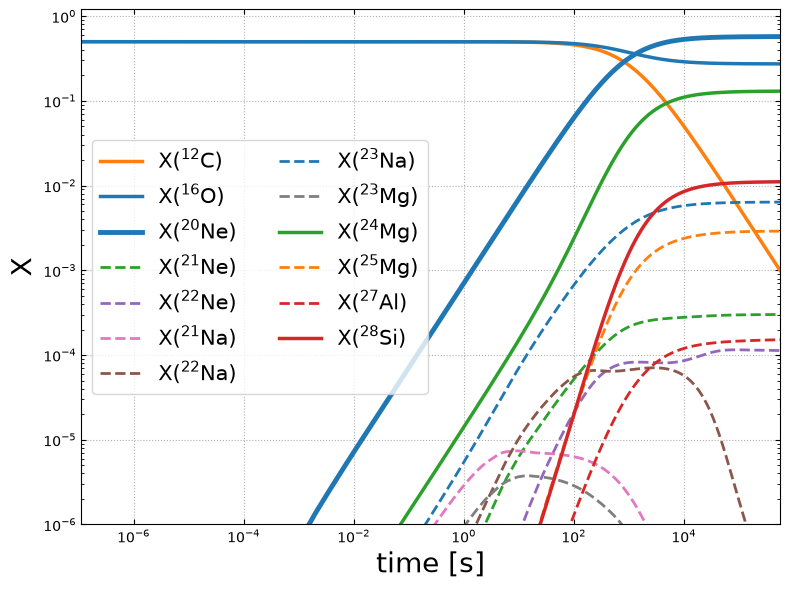

In [7]:
fig = sol.plot_evolution(three_level_style=True, ymin=1.e-6)

We can access the composition at the final time (we use a negative time to have it evaluate at the endpoint of integration)

In [8]:
comp = sol.comp_at(-1)

We can visualize the fractions of the final composition:

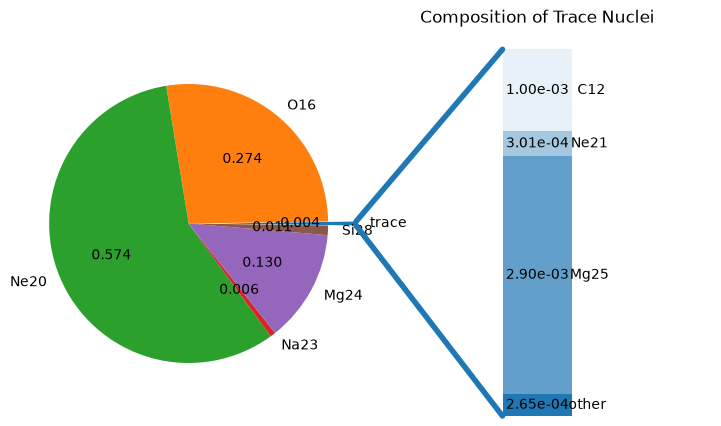

In [9]:
fig = comp.plot(trace_threshold=5.e-3)

Now we see that the major products after ${}^{20}\mathrm{Ne}$ are ${}^{24}\mathrm{Mg}$ and then the two Urca nuclei: ${}^{23}\mathrm{Na}$ and ${}^{25}\mathrm{Mg}$.  These are the nuclei that the Schwab et al. paper focuses on.

To understand where they came from, we can visualize the flow through the network at the end of our burn.

/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:129: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))


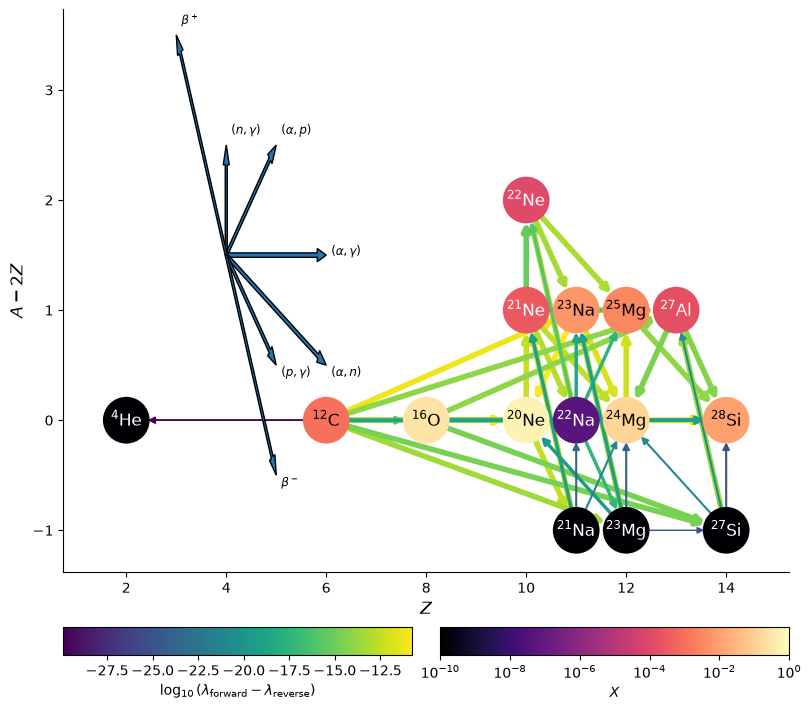

In [10]:
fig = net.plot(rho=rho, T=T, comp=comp, rotated=True,
               color_nodes_by_abundance=True,
               legend_coord=(4, 1.5),
               size=(800, 700),
               use_net_rate=True)

We see that ${}^{23}\mathrm{Na}$ is primarily made by ${}^{12}\mathrm{C} + {}^{12}\mathrm{C}$
while ${}^{25}\mathrm{Mg}$ is made via $(n,\gamma)$ and $(\alpha, n)$ reactions.